In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import FastMarkerCluster
import webbrowser

In [3]:
df = pd.read_parquet("final_data_chicago_crimes_2001_to_2017.parquet")

In [4]:
print(f"Nombre de ligne : {df.shape[0]}")
print(f"Nombre de colonne : {df.shape[1]}")

Nombre de ligne : 6085064
Nombre de colonne : 16


In [5]:
df.head()

,ID,Date,Primary Type,Description,Location Description,Arrest,Domestic,District,FBI Code,Updated On,Latitude,Longitude,Hour,Day,Month,Year
0,4676906,2003-03-01 00:00:00,OTHER OFFENSE,HARASSMENT BY TELEPHONE,RESIDENCE,False,True,9,26,2016-04-15 08:55:02,41.817229,-87.637328,0,Saturday,March,2003
1,4677901,2003-05-01 01:00:00,THEFT,FINANCIAL ID THEFT:$300 &UNDER,RESIDENCE,False,False,22,06,2016-04-15 08:55:02,41.691785,-87.635116,1,Thursday,May,2003
2,4791194,2001-01-01 11:00:00,CRIM SEXUAL ASSAULT,PREDATORY,RESIDENCE,True,True,5,02,2006-08-29 03:46:28,41.687020,-87.608445,11,Monday,January,2001
3,4679521,2003-03-15 00:00:00,OTHER OFFENSE,OTHER WEAPONS VIOLATION,RESIDENCE PORCH/HALLWAY,False,False,22,26,2016-04-15 08:55:02,41.729712,-87.653159,0,Saturday,March,2003
4,4680124,2003-01-01 00:00:00,THEFT,FINANCIAL ID THEFT: OVER $300,RESIDENCE,False,False,11,06,2016-04-15 08:55:02,41.869772,-87.708180,0,Wednesday,January,2003


In [6]:
if (df.duplicated().sum() > 0):
    print(f"Nombre de doublon : {df.duplicated().sum()}")
    print(f"Suppression des doublons...")
    df.drop_duplicates(inplace=True)
    print(f"Nombre de doublon restant : {df.duplicated().sum()}")
else:
    print("Aucun doublon !")

Aucun doublon !


In [7]:
print(f"Nombre de ligne : {df.shape[0]}")
print(f"Nombre de colonne : {df.shape[1]}")

Nombre de ligne : 6085064
Nombre de colonne : 16


In [8]:
df.isnull().sum()

ID                      0
Date                    0
Primary Type            0
Description             0
Location Description    0
Arrest                  0
Domestic                0
District                0
FBI Code                0
Updated On              0
Latitude                0
Longitude               0
Hour                    0
Day                     0
Month                   0
Year                    0
dtype: int64

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6085064 entries, 0 to 6085063
Data columns (total 16 columns):
 #   Column                Dtype         
---  ------                -----         
 0   ID                    str           
 1   Date                  datetime64[us]
 2   Primary Type          str           
 3   Description           str           
 4   Location Description  str           
 5   Arrest                bool          
 6   Domestic              bool          
 7   District              str           
 8   FBI Code              str           
 9   Updated On            datetime64[us]
 10  Latitude              float64       
 11  Longitude             float64       
 12  Hour                  int64         
 13  Day                   str           
 14  Month                 str           
 15  Year                  str           
dtypes: bool(2), datetime64[us](2), float64(2), int64(1), str(9)
memory usage: 1.0 GB


In [16]:
df["Date"].describe().reset_index()

,index,Date
0,count,6085064
1,mean,2008-02-16 22:54:56.290485
2,min,2001-01-01 00:00:00
3,25%,2004-05-25 12:00:00
4,50%,2007-10-05 23:00:00
5,75%,2011-09-12 14:15:00
6,max,2017-01-18 10:12:00


In [17]:
df["Hour"].describe().reset_index()

,index,Hour
0,count,6.085064e+06
1,mean,1.322401e+01
2,std,6.752033e+00
3,min,0.000000e+00
4,25%,9.000000e+00
5,50%,1.400000e+01
6,75%,1.900000e+01
7,max,2.300000e+01


In [18]:
df.describe(include=['str', 'bool'])

,ID,Primary Type,Description,Location Description,Arrest,Domestic,District,FBI Code,Day,Month,Year
count,6085064,6085064,6085064,6085064,6085064,6085064,6085064,6085064,6085064,6085064,6085064
unique,6085064,35,375,170,2,2,26,26,7,12,17
top,4676906,THEFT,SIMPLE,STREET,False,False,8,06,Friday,July,2001
freq,1,1264298,725349,1619140,4360044,5298287,418709,1264298,916530,574404,482851


In [19]:
print("Top 10 des catégories de crime en pourcentage (%)")
round(((df["Primary Type"].value_counts().head(10)*100)/df.shape[0]), 2).reset_index()

Top 10 des catégories de crime en pourcentage (%)


,Primary Type,count
0,THEFT,20.78
1,BATTERY,18.33
2,CRIMINAL DAMAGE,11.57
3,NARCOTICS,10.91
4,OTHER OFFENSE,6.19
5,ASSAULT,6.14
6,BURGLARY,5.89
7,MOTOR VEHICLE THEFT,4.71
8,ROBBERY,3.79
9,DECEPTIVE PRACTICE,3.48


In [20]:
print("Top 10 des types d'endroit où le crime à été commis en pourcentage (%)")
round(((df["Location Description"].value_counts().head(10)*100)/df.shape[0]), 2).reset_index()

Top 10 des types d'endroit où le crime à été commis en pourcentage (%)


,Location Description,count
0,STREET,26.61
1,RESIDENCE,16.81
2,APARTMENT,10.17
3,SIDEWALK,10.08
4,OTHER,3.74
5,PARKING LOT/GARAGE(NON.RESID.),2.87
6,ALLEY,2.27
7,"SCHOOL, PUBLIC, BUILDING",2.17
8,RESIDENCE-GARAGE,1.99
9,RESIDENCE PORCH/HALLWAY,1.76


In [21]:
print(list(df["Location Description"].unique()))

['RESIDENCE', 'RESIDENCE PORCH/HALLWAY', 'APARTMENT', 'OTHER', 'GAS STATION', 'COMMERCIAL / BUSINESS OFFICE', 'STREET', 'BANK', 'APPLIANCE STORE', 'PARKING LOT/GARAGE(NON.RESID.)', 'CHURCH/SYNAGOGUE/PLACE OF WORSHIP', 'DAY CARE CENTER', 'HOSPITAL BUILDING/GROUNDS', 'HOTEL/MOTEL', 'SCHOOL, PRIVATE, GROUNDS', 'VEHICLE NON-COMMERCIAL', 'ALLEY', 'SMALL RETAIL STORE', 'DEPARTMENT STORE', 'RESTAURANT', 'MEDICAL/DENTAL OFFICE', 'CHA STAIRWELL', 'AUTO', 'BASEMENT', 'ABANDONED BUILDING', 'RETAIL STORE', 'TAVERN', 'GAS STATION DRIVE/PROP.', 'HOTEL', 'HALLWAY', 'TRUCK', 'GANGWAY', 'PARKING LOT', 'FACTORY/MANUFACTURING BUILDING', 'HOUSE', 'COACH HOUSE', 'PORCH', 'CLUB', 'SCHOOL, PUBLIC, BUILDING', 'VACANT LOT', 'YARD', 'CURRENCY EXCHANGE', 'SIDEWALK', 'AIRPORT BUILDING NON-TERMINAL - SECURE AREA', 'CHA APARTMENT', 'CAR WASH', 'CHA PARKING LOT', 'LOADING DOCK', 'CHA ELEVATOR', 'LAKE', 'RAILROAD PROPERTY', 'VESTIBULE', 'CHA HALLWAY', 'GOVERNMENT BUILDING/PROPERTY', 'AIRPORT TERMINAL UPPER LEVEL - SE

In [24]:
Name_Location_Description = input("Enter Location Description : ")
Number_Rows_Location_Description = int(input("Number Rows Output : "))

if (Name_Location_Description not in list(df["Location Description"].unique())):
    print("Vous devez entrer un nom de la variable 'Location Description' !!!")
else:
    print(f"Top {Number_Rows_Location_Description} des catégories de crime commis dans '{Name_Location_Description}' en pourcentage (%)")

Name_Location_Description_df = df[df["Location Description"] == Name_Location_Description]
round(((Name_Location_Description_df["Primary Type"].value_counts()*100)/Name_Location_Description_df.shape[0]), 2).reset_index().head(Number_Rows_Location_Description)

Top 10 des catégories de crime commis dans 'GOVERNMENT BUILDING' en pourcentage (%)


,Primary Type,count
0,HOMICIDE,100.0


In [28]:
print("Liste des Districts avec le plus de crime en pourcentage (%)")
round(((df["District"].value_counts()*100)/df.shape[0]), 5).reset_index()

Liste des Districts avec le plus de crime en pourcentage (%)


,District,count
0,8,6.88093
1,11,6.34103
2,7,5.96888
3,25,5.83152
4,6,5.73923
5,4,5.70114
6,3,5.12249
7,9,5.02075
8,12,4.88596
9,2,4.84006


In [23]:
Name_District = input("Enter a District : ")
Number_Rows_District = int(input("Number Rows Output : "))

if (Name_District not in list(df["District"].unique())):
    print("Vous devez entrer un nom de la varible 'District' !!!")
else:
    print(f"Top {Number_Rows_District} des catégories de crime commis dans le district '{Name_District}' en pourcentage (%)")

Name_District_df = df[df["District"] == Name_District]
round(((Name_District_df["Primary Type"].value_counts()*100)/Name_District_df.shape[0]), 2).reset_index().head(Number_Rows_District)

Top 10 des catégories de crime commis dans le district '7' en pourcentage (%)


,Primary Type,count
0,BATTERY,24.79
1,THEFT,13.30
2,NARCOTICS,12.63
3,CRIMINAL DAMAGE,11.22
4,ASSAULT,7.65
5,BURGLARY,6.28
6,OTHER OFFENSE,5.37
7,ROBBERY,4.34
8,MOTOR VEHICLE THEFT,4.17
9,CRIMINAL TRESPASS,2.16


In [30]:
print("Les codes du FBI par ordre du plus fréquent en pourcentage (%)")
round(((df["FBI Code"].value_counts()*100)/df.shape[0]), 4).reset_index()

Les codes du FBI par ordre du plus fréquent en pourcentage (%)


,FBI Code,count
0,06,20.7771
1,08B,15.6909
2,14,11.5695
3,26,10.2886
4,18,10.2203
5,05,5.8921
6,07,4.7134
7,08A,4.6312
8,03,3.7939
9,11,2.8881


In [33]:
print('Arrestations éffectuer !')
round(((df.groupby('Arrest')['ID'].count()*100)/df.shape[0]), 2).reset_index()

Arrestations éffectuer !


,Arrest,ID
0,False,71.65
1,True,28.35


In [34]:
print('Crimes Domestique !')
round(((df.groupby('Domestic')['ID'].count()*100)/df.shape[0]), 2).reset_index()

Crimes Domestique !


,Domestic,ID
0,False,87.07
1,True,12.93


# Visualisation

In [35]:
df.head()

,ID,Date,Primary Type,Description,Location Description,Arrest,Domestic,District,FBI Code,Updated On,Latitude,Longitude,Hour,Day,Month,Year
0,4676906,2003-03-01 00:00:00,OTHER OFFENSE,HARASSMENT BY TELEPHONE,RESIDENCE,False,True,9,26,2016-04-15 08:55:02,41.817229,-87.637328,0,Saturday,March,2003
1,4677901,2003-05-01 01:00:00,THEFT,FINANCIAL ID THEFT:$300 &UNDER,RESIDENCE,False,False,22,06,2016-04-15 08:55:02,41.691785,-87.635116,1,Thursday,May,2003
2,4791194,2001-01-01 11:00:00,CRIM SEXUAL ASSAULT,PREDATORY,RESIDENCE,True,True,5,02,2006-08-29 03:46:28,41.687020,-87.608445,11,Monday,January,2001
3,4679521,2003-03-15 00:00:00,OTHER OFFENSE,OTHER WEAPONS VIOLATION,RESIDENCE PORCH/HALLWAY,False,False,22,26,2016-04-15 08:55:02,41.729712,-87.653159,0,Saturday,March,2003
4,4680124,2003-01-01 00:00:00,THEFT,FINANCIAL ID THEFT: OVER $300,RESIDENCE,False,False,11,06,2016-04-15 08:55:02,41.869772,-87.708180,0,Wednesday,January,2003


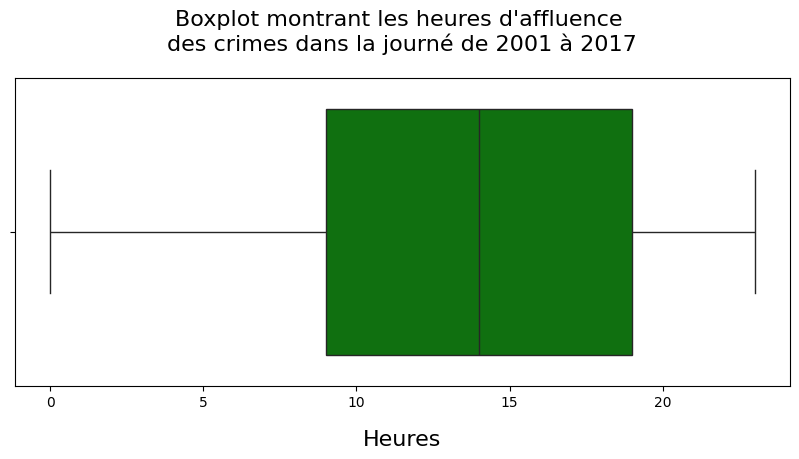

In [55]:
plt.figure(figsize=(10, 4))
sns.boxplot(data=df, x='Hour', color='green')
plt.title("Boxplot montrant les heures d'affluence \ndes crimes dans la journé de 2001 à 2017", fontsize='16', pad=20)
plt.xlabel('Heures', fontsize='16', labelpad=14)
plt.show()

* Le graphique de gauche nous montre les heures à la quel il y a plus de crime 
lorsqu'on est dans une maison familiale d'une part et hors d'autre part

* Le graphique de droite nous montre les heures des crimes 
où il y a eu des arrestations et où il n'y a pas eu d'arrestation


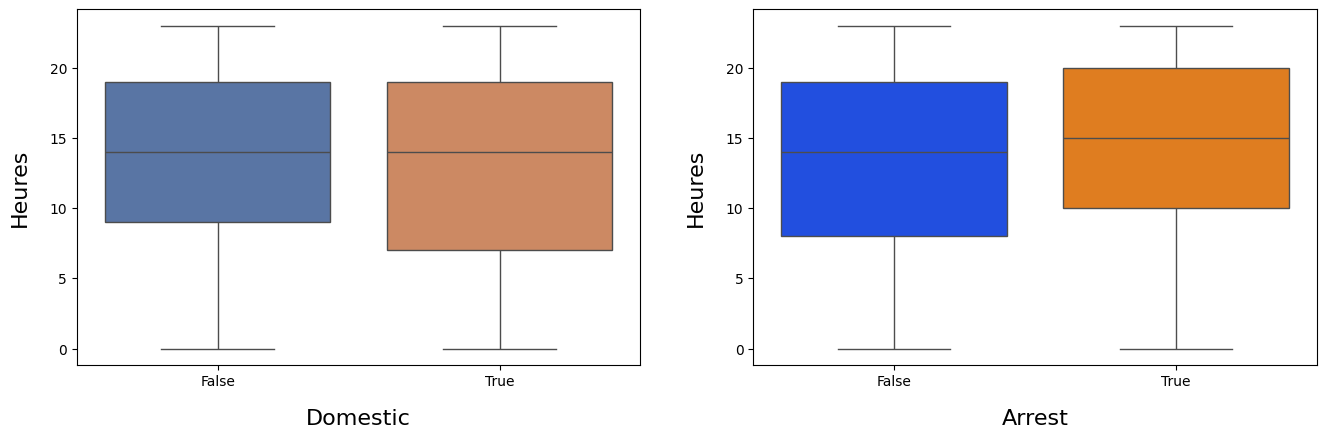

In [61]:
print("* Le graphique de gauche nous montre les heures à la quel il y a plus de crime \nlorsqu'on est dans une maison familiale d'une part et hors d'autre part\n")
print("* Le graphique de droite nous montre les heures des crimes \noù il y a eu des arrestations et où il n'y a pas eu d'arrestation")

plt.figure(figsize=(16, 12))

plt.subplot(2, 2, 1)
sns.boxplot(data=df, x='Domestic', y='Hour', hue='Domestic', palette='deep', legend=False)
plt.xlabel('Domestic', fontsize='16', labelpad=14)
plt.ylabel('Heures', fontsize='16', labelpad=14)

plt.subplot(2, 2, 2)
sns.boxplot(data=df, x='Arrest', y='Hour', hue='Arrest', palette='bright', legend=False)
plt.xlabel('Arrest', fontsize='16', labelpad=14)
plt.ylabel('Heures', fontsize='16', labelpad=14)

plt.subplots_adjust(wspace=0.2, hspace=0.6)
plt.show()

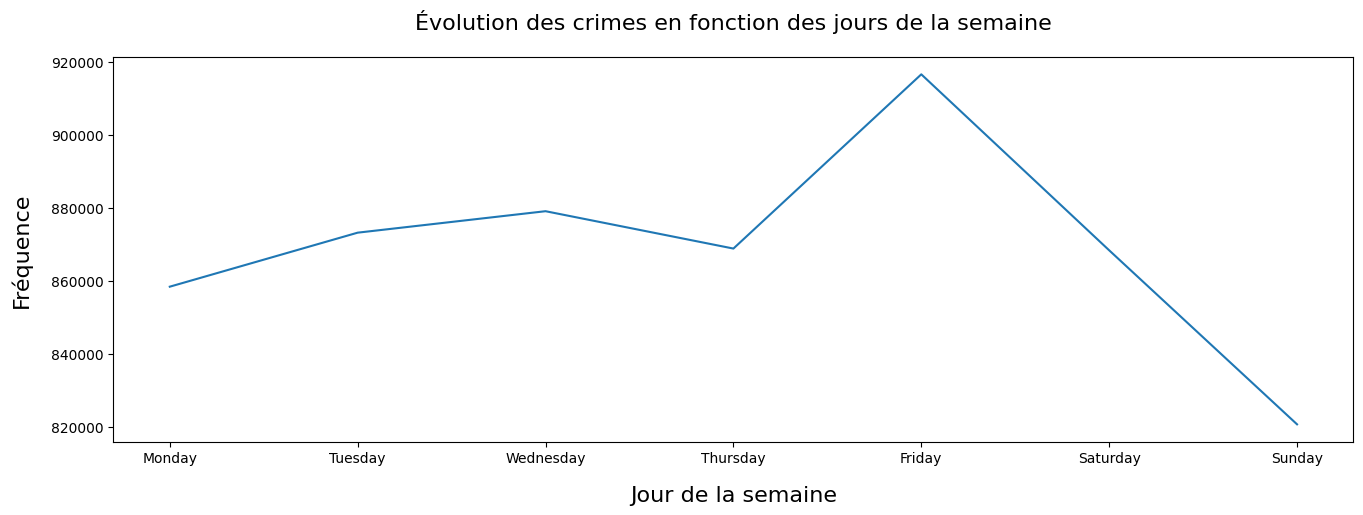

In [69]:
ordre = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['Day'] = pd.Categorical(df['Day'], categories=ordre, ordered=True)
counts = df['Day'].value_counts().sort_index()

plt.figure(figsize=(16, 5))
sns.lineplot(x=counts.index, y=counts.values)
plt.title("Évolution des crimes en fonction des jours de la semaine", fontsize='16', pad=20)
plt.xlabel('Jour de la semaine', fontsize='16', labelpad=14)
plt.ylabel('Fréquence', fontsize='16', labelpad=14)
plt.show()

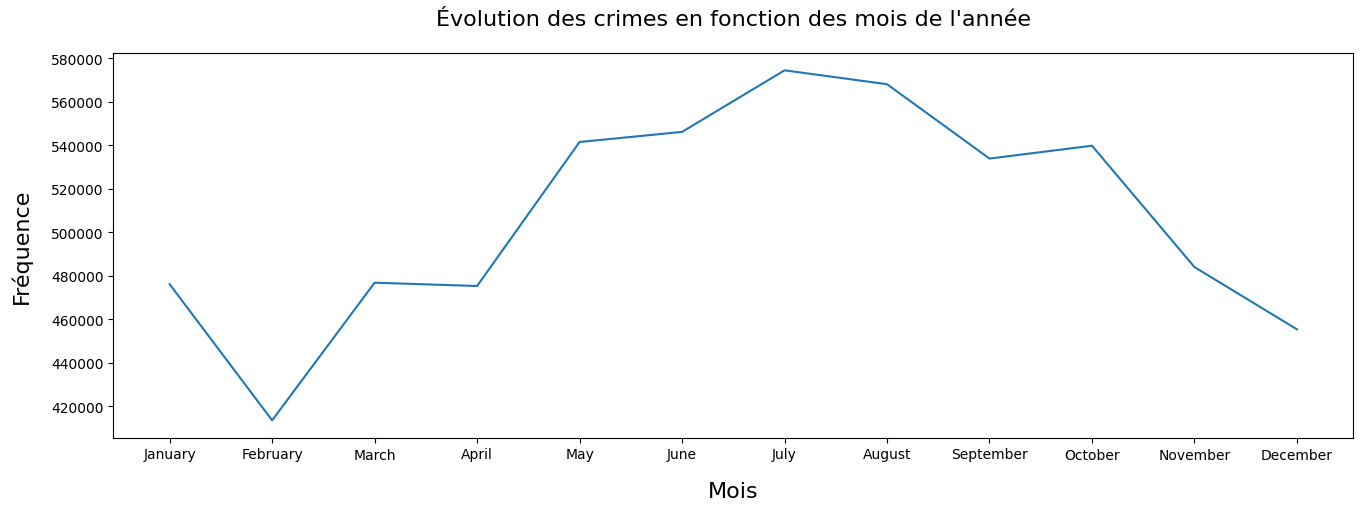

In [70]:
ordre = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
df['Month'] = pd.Categorical(df['Month'], categories=ordre, ordered=True)
counts = df['Month'].value_counts().sort_index()

plt.figure(figsize=(16, 5))
sns.lineplot(x=counts.index, y=counts.values)
plt.title("Évolution des crimes en fonction des mois de l'année", fontsize='16', pad=20)
plt.xlabel('Mois', fontsize='16', labelpad=14)
plt.ylabel('Fréquence', fontsize='16', labelpad=14)
plt.show()

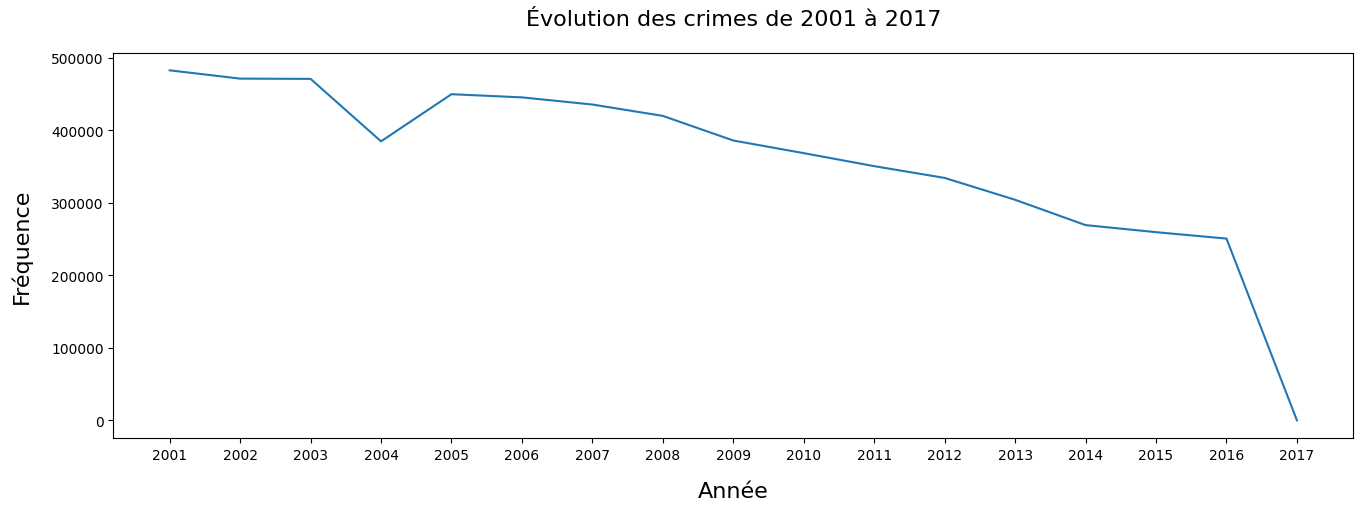

In [71]:
plt.figure(figsize=(16, 5))
counts = df['Year'].value_counts().sort_index()
sns.lineplot(x=counts.index, y=counts.values)
plt.title("Évolution des crimes de 2001 à 2017", fontsize='16', pad=20)
plt.xlabel('Année', fontsize='16', labelpad=14)
plt.ylabel('Fréquence', fontsize='16', labelpad=14)
plt.show()

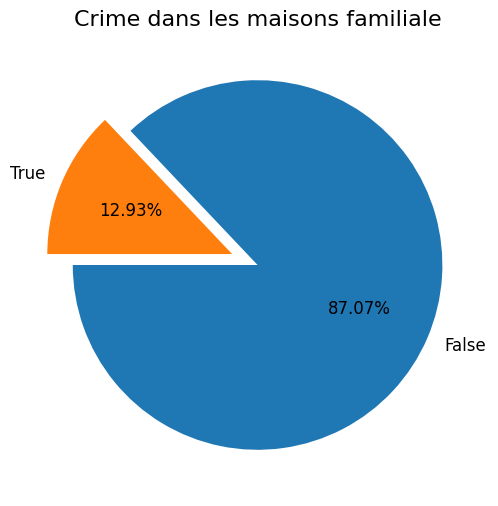

In [156]:
plt.figure(figsize=(6, 6))
domestic = df['Domestic'].value_counts()
label = ['False', 'True']
explode = (0, 0.15)
plt.pie(domestic, autopct='%1.2f%%', labeldistance=1.1, labels=label, explode=explode, startangle=180, textprops={'fontsize': 12, 'weight': 'light'})
plt.title("Crime dans les maisons familiale", fontsize='16')
plt.show()

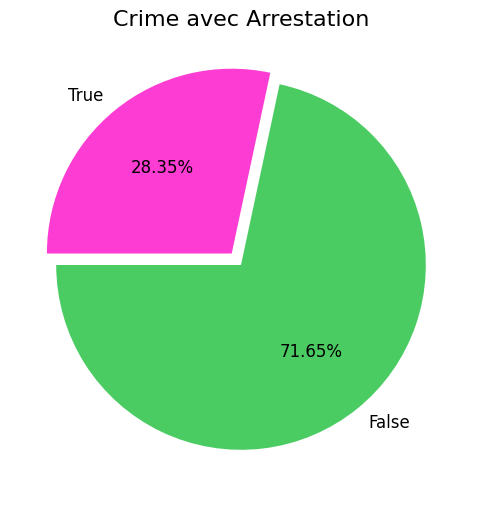

In [161]:
plt.figure(figsize=(6, 6))
arrest = df['Arrest'].value_counts()
label = ['False', 'True']
explode = (0, 0.08)
color = ['#4BCC63', '#FD3CD4']
plt.pie(arrest, autopct='%1.2f%%', labeldistance=1.1, labels=label, explode=explode, startangle=180, colors=color, textprops={'fontsize': 12, 'weight': 'light'})
plt.title("Crime avec Arrestation", fontsize='16')
plt.show()

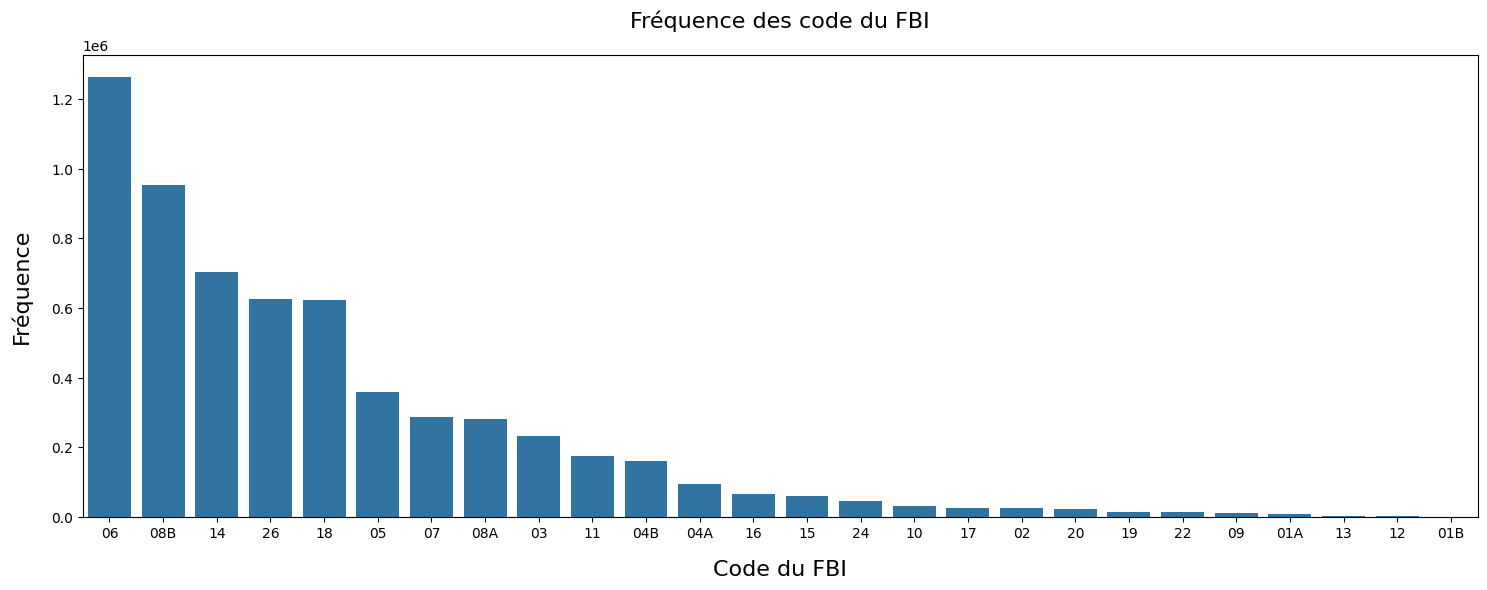

In [162]:
plt.figure(figsize=(18, 6))
sns.countplot(data=df, x='FBI Code', order=df['FBI Code'].value_counts(ascending=False).index)
plt.title('Fréquence des code du FBI', fontsize='16', pad=20)
plt.xlabel('Code du FBI', fontsize='16', labelpad=14)
plt.ylabel('Fréquence', fontsize='16', labelpad=14)
plt.show()

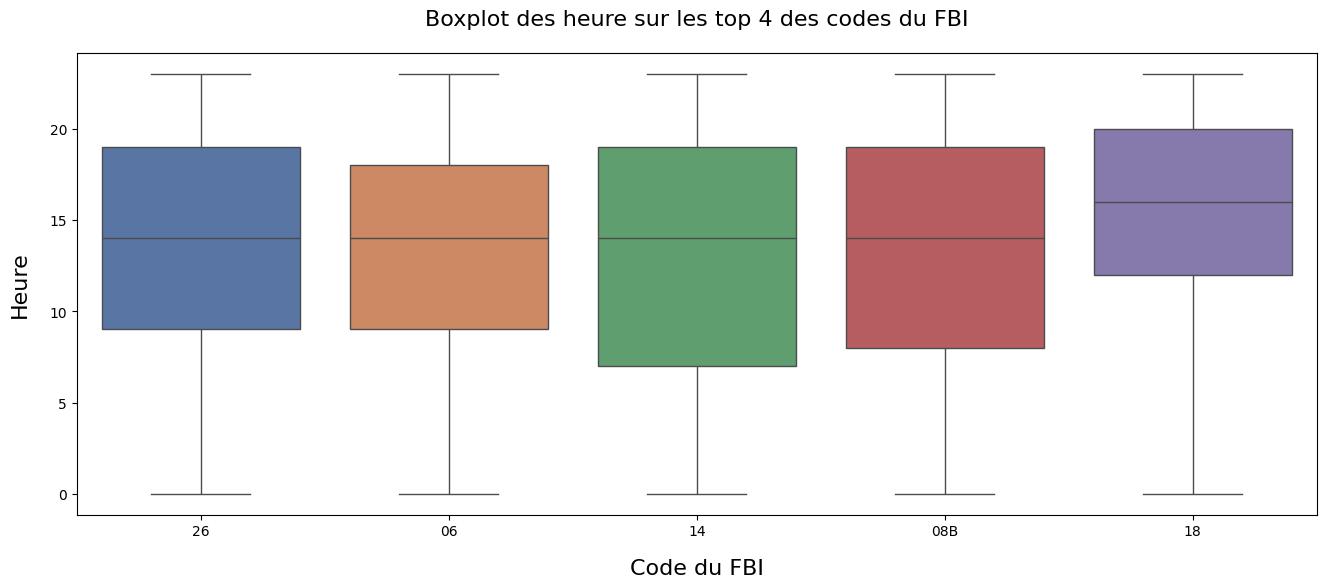

In [ ]:
top_five_FBICode = df[df['FBI Code'].isin(['06', '08B', '14', '26', '18'])]
plt.figure(figsize=(16, 6))
sns.boxplot(data=top_five_FBICode, x='FBI Code', y='Hour', hue='FBI Code', palette='deep', legend=False)
plt.title('Boxplot des heure sur les top 4 des codes du FBI', fontsize='16', pad=20)
plt.xlabel('Code du FBI', fontsize='16', labelpad=14)
plt.ylabel('Heures', fontsize='16', labelpad=14)
plt.show()

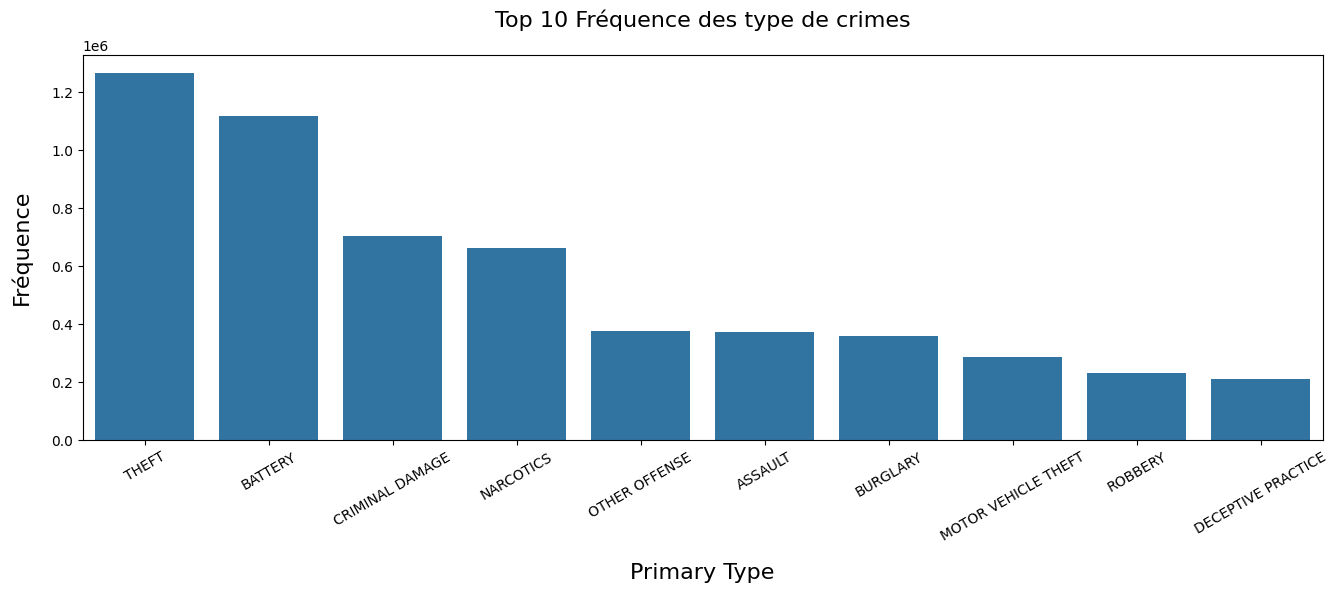

In [168]:
plt.figure(figsize=(16, 5))
sns.countplot(data=df, x='Primary Type', order=df['Primary Type'].value_counts(ascending=False).head(10).index)
plt.title('Top 10 Fréquence des type de crimes', fontsize='16', pad=20)
plt.xlabel('Primary Type', fontsize='16', labelpad=14)
plt.ylabel('Fréquence', fontsize='16', labelpad=14)
plt.xticks(rotation=30)
plt.show()

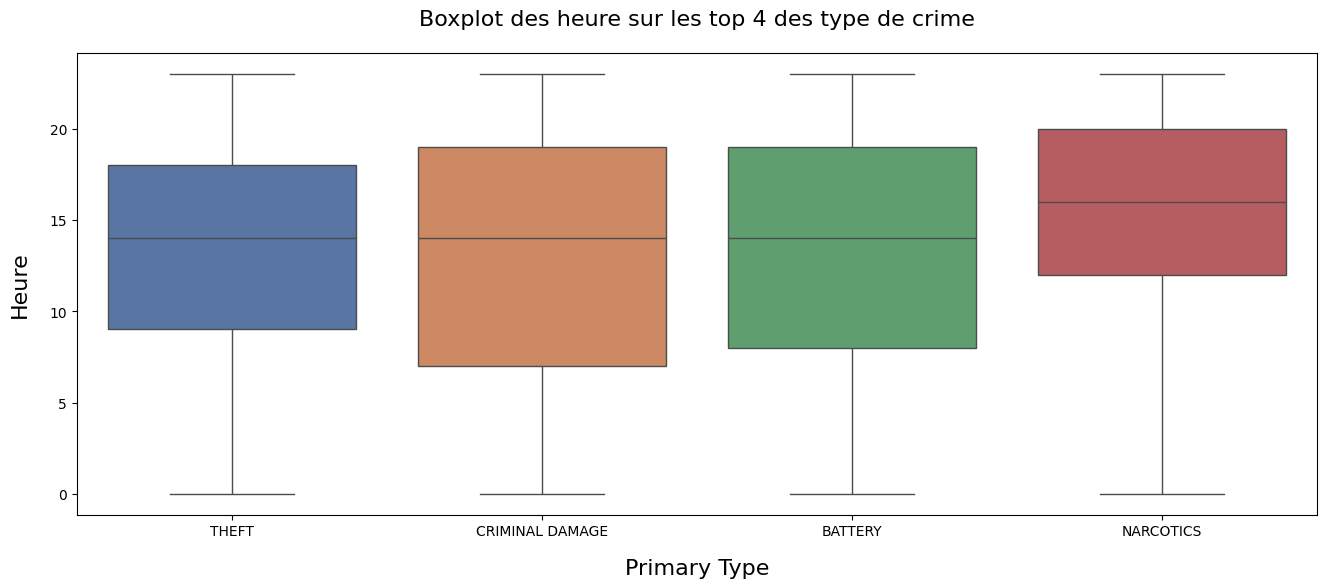

In [ ]:
top_four_PrimaryType = df[df['Primary Type'].isin(['THEFT', 'BATTERY', 'CRIMINAL DAMAGE', 'NARCOTICS'])]
plt.figure(figsize=(16, 6))
sns.boxplot(data=top_four_PrimaryType, x='Primary Type', y='Hour', hue='Primary Type', palette='deep', legend=False)
plt.title('Boxplot des heure sur les top 4 des type de crime', fontsize='16', pad=20)
plt.xlabel('Primary Type', fontsize='16', labelpad=14)
plt.ylabel('Heures', fontsize='16', labelpad=14)
plt.show()

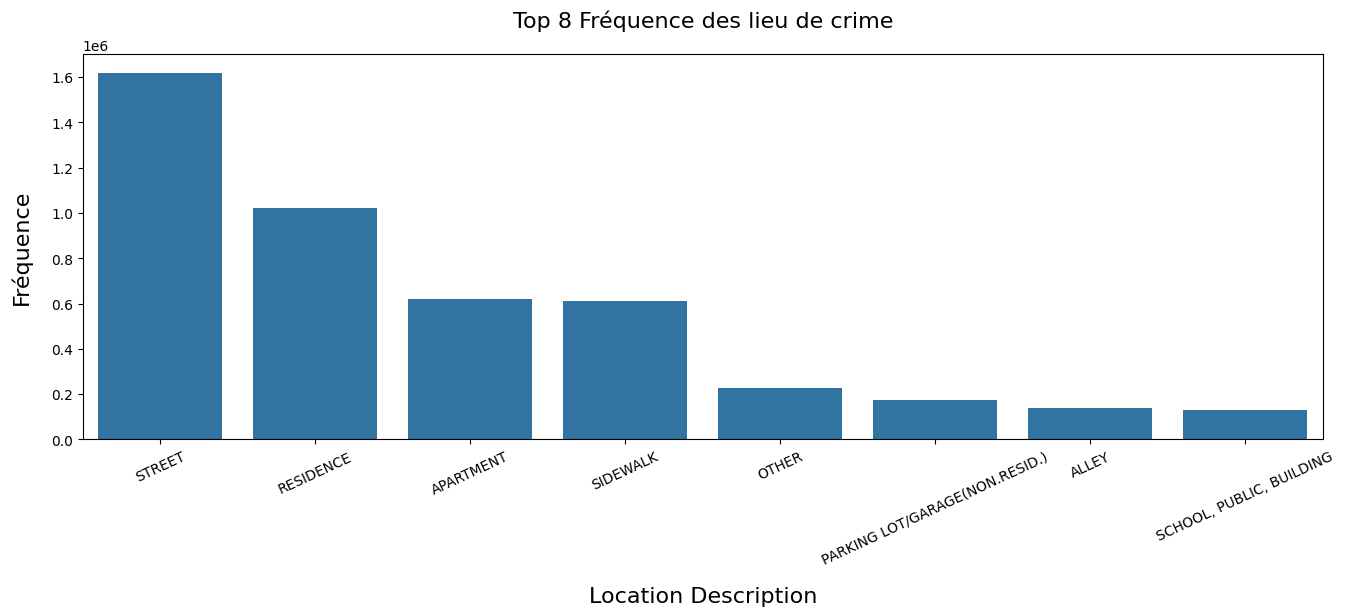

In [170]:
plt.figure(figsize=(16, 5))
sns.countplot(data=df, x='Location Description', order=df['Location Description'].value_counts(ascending=False).head(8).index)
plt.title('Top 8 Fréquence des lieu de crime', fontsize='16', pad=20)
plt.xlabel('Location Description', fontsize='16', labelpad=14)
plt.ylabel('Fréquence', fontsize='16', labelpad=14)
plt.xticks(rotation=25)
plt.show()

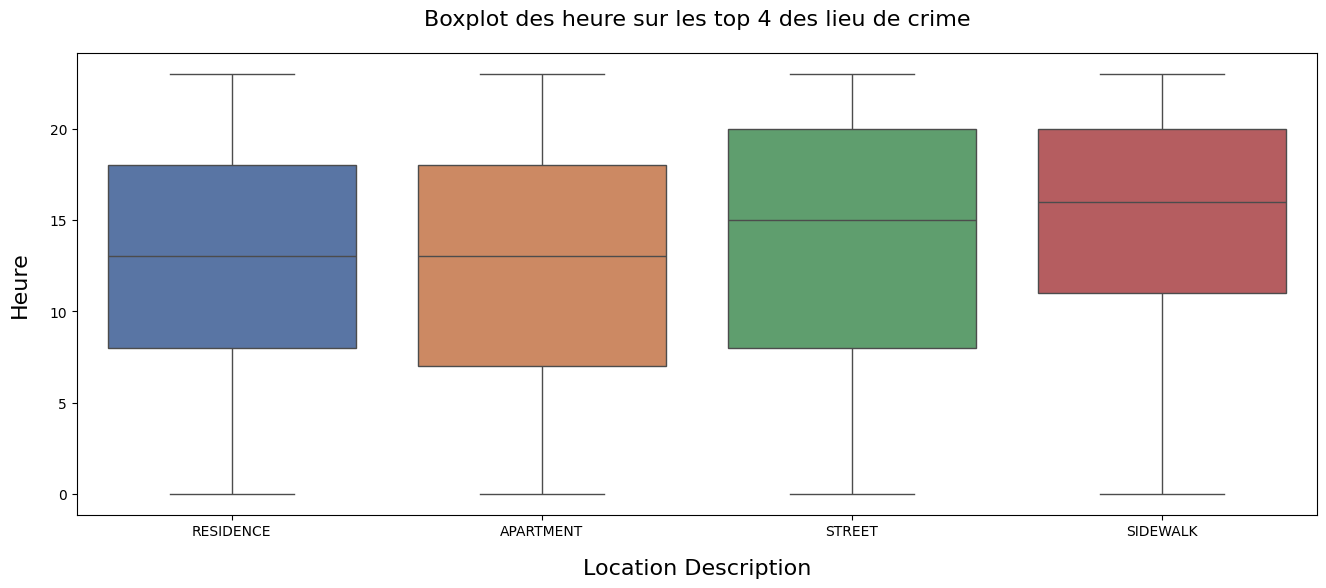

In [ ]:
top_four_LocationDescription = df[df['Location Description'].isin(['STREET', 'RESIDENCE', 'APARTMENT', 'SIDEWALK'])]
plt.figure(figsize=(16, 6))
sns.boxplot(data=top_four_LocationDescription, x='Location Description', y='Hour', hue='Location Description', palette='deep', legend=False)
plt.title('Boxplot des heure sur les top 4 des lieu de crime', fontsize='16', pad=20)
plt.xlabel('Location Description', fontsize='16', labelpad=14)
plt.ylabel('Heures', fontsize='16', labelpad=14)
plt.show()

In [174]:
print("Liste des Districts")
print(list(df['District'].unique()))

Liste des Districts
['9', '22', '5', '11', '8', '14', '7', '16', '15', '3', '1', '10', '2', '25', '19', '6', '4', '12', '18', '17', '24', '20', '31', '21', '23', '13']


In [ ]:
print("Carte affichant le District avec le lieu de crime")
district = input("Entrer un dstrict : ")

df_map = df[df['District'].astype(str) == str(district)]

if df_map.empty:
    print(f"Aucun crime trouvé dans le district {district}")
else:
    centre_lat = df_map['Latitude'].mean()
    centre_lon = df_map['Longitude'].mean()

    ma_carte = folium.Map(
        location=[centre_lat, centre_lon],
        zoom_start=11
    )

locations = df_map[["Latitude", "Longitude"]].dropna().values.tolist()

FastMarkerCluster(locations).add_to(ma_carte)

print(f"Lieu des crimes réalisés dans le district '{district}' à Chicago")

ma_carte.save("carte_crimes.html")
webbrowser.open("carte_crimes.html")

Carte affichant le District avec le lieu de crime
Lieu des crimes réalisés dans le district '31' à Chicago


True